# T12 — What you seed is what you get: mode selection, and three things that do not help

**Cluster D — Part 3, lithospheric deformation.** Requires the container.

Continental rifts come in modes. Buck (1991) put them on a diagram: **narrow**
rifts where the lithosphere is thick, cold and strong; **wide** rifts where it is
hot and weak and a ductile lower crust spreads the deformation; core complexes
at the extreme. It is one of the most reproduced figures in the subject, and
reproducing it was the plan for this notebook.

**It is not what you are about to see.** Four separate attempts failed to
produce the transition, and each failed for a reason worth more than the figure
would have been. This notebook is that investigation, written up as it
happened, because the alternative — quietly tuning until a plausible picture
appears — is the thing this suite exists to argue against.

## Learning objectives

1. Set up a comparative geotherm experiment without accidentally changing the planet between cases.
2. Build a diagnostic that measures a *distribution* rather than an amount, and test it before trusting it.
3. Recognise when an initial condition is imposing the answer you are trying to measure.
4. Work out, from the non-dimensionalisation, which knobs can buy you finite strain and which cannot.

## Prerequisites and runtime

* T10, T11. **Requires the container.**
* **Measured runtime: 11 minutes.** Three model runs, one of which is
  expected to abort.

In [1]:
# === USER CONFIGURATION ===
NX, NY = 48, 24            # coarse on purpose; section 7 explains the ceiling
STEPS = 20
CRUSTS = (20.0, 35.0, 50.0)

In [2]:
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting, lithosphere as LI

DRIVER = os.path.join("..", "tools", "gadopt_rift_case.py")


def run(tag, **kw):
    """Run the rift driver. Returns its RESULT dict (even when it aborts)."""
    cmd = [sys.executable, DRIVER, "--nx", str(NX), "--ny", str(NY),
           "--thermal", "--free-surface", "--out", f"{tag}.npz"]
    for k, v in kw.items():
        flag = f"--{k.replace('_', '-')}"
        cmd += [flag] if v is True else [flag, str(v)]
    p = subprocess.run(cmd, capture_output=True, text=True)
    for line in p.stdout.splitlines():
        if line.startswith("RESULT "):
            return json.loads(line[len("RESULT "):])
    raise RuntimeError(f"no result:\n{p.stderr[-1500:]}")

## 1. Setting up the experiment without changing the planet

The obvious control is surface heat flow: raise it for a hot, weak lithosphere,
lower it for a cold, strong one. The driver used to work that way, and it was
wrong.

The geotherm is integrated *downwards* from the surface flux, so specifying
$q_0$ and reading off whatever basal temperature results lets the **mantle
potential temperature drift between cases**. Sweeping $q_0$ from 0.048 to 0.065
would have swept the base of the lithosphere from 1060 °C to 1940 °C. That is
not a geotherm experiment; it is four different planets.

Pin the base instead — it is the mantle adiabat, about 1340 °C — and let the
surface flux be whatever the column requires. The steady conductive profile is
affine in $q_0$, so inverting for it is exact rather than iterative.

In [3]:
print(f"{'crust':>6} {'q0':>8} {'T(Moho)':>9} {'strength':>11}   prediction")
pred = {}
for ck in CRUSTS:
    col = LI.scaled_column(ck)
    q = LI.heat_flow_for_base_temperature(1613.0, col)
    env = LI.strength_envelope(column=col, surface_heat_flow=q)
    Tm = float(np.atleast_1d(LI.geotherm(ck, column=col, surface_heat_flow=q))[0]) - 273
    F = np.trapezoid(env["strength_MPa"], env["depth_km"]) * 1e6 * 1e3 / 1e12
    pred[ck] = "narrow" if Tm < 500 else "wide"
    print(f"{ck:6.0f} {q:8.4f} {Tm:8.0f}C {F:8.1f} TN/m   {pred[ck]}")
print("\nBase of the column is 1340 C in every case, by construction.")

 crust       q0   T(Moho)    strength   prediction
    20   0.0451      296C     34.4 TN/m   narrow
    35   0.0527      539C     27.2 TN/m   wide
    50   0.0593      779C     19.3 TN/m   wide

Base of the column is 1340 C in every case, by construction.


**That table is the prediction, and it is made before any solver runs.** Thin
crust puts the Moho at under 300 °C, so the crust is strong and welded to a
strong mantle lithosphere — Buck's narrow rift. Thick crust puts it near 780 °C,
where wet anorthite flows freely, decoupling the brittle upper crust — Buck's
wide rift.

## 2. A metric that measures a distribution

Narrow versus wide is a statement about the **width of the deforming zone**, so
an amount will not do. Take the column-integrated increment in plastic strain,
normalise it to a probability, and ask what fraction of the domain carries half
the total. Call it $W_{50}$.

Test it before trusting it — this model has already defeated three diagnostics:

In [4]:
def w50(field):
    col = np.maximum(field, 0.0).sum(axis=0)
    tot = col.sum()
    if tot <= 0:
        return None
    p = np.sort(col / tot)[::-1]
    return round(float((np.searchsorted(np.cumsum(p), 0.5) + 1) / p.size), 4)


n = 200
x = np.arange(n)
cases = [
    ("uniform (maximally wide)", np.ones((10, n))),
    ("one column (maximally narrow)", np.pad(np.ones((10, 1)), ((0, 0), (0, n - 1)))),
    ("gaussian, sigma = 5", np.tile(np.exp(-((x - 100) / 5.) ** 2), (10, 1))),
    ("gaussian, sigma = 30", np.tile(np.exp(-((x - 100) / 30.) ** 2), (10, 1))),
    ("nothing deforms", np.zeros((10, n))),
]
for name, f in cases:
    print(f"{name:>32}   W50 = {w50(f)}")

        uniform (maximally wide)   W50 = 0.5
   one column (maximally narrow)   W50 = 0.005
             gaussian, sigma = 5   W50 = 0.025
            gaussian, sigma = 30   W50 = 0.145
                 nothing deforms   W50 = None


The last row is the important one. A metric that scored an undeformed model as
"narrow" would be worse than useless here, because that is exactly the failure
mode a strong lithosphere produces. This one returns `None`, and a *nearly*
undeformed model returns 0.5 — the honest reading of "no localisation".

It still is not sufficient on its own. Keep peak strain beside it: two runs can
share a $W_{50}$ while one has genuinely spread its deformation and the other
has barely deformed at all. That happened in the first sweep, at 20 and 50 km.

## 3. Attempt one: the centred seed imposes the answer

T10 and T11 place a weak patch at the domain centre, with plastic strain already
past the weakening onset. That is right for asking *how* a rift localises once
it has somewhere to nucleate.

It is wrong for asking *whether* it localises to one place. Measured over four
crustal thicknesses with that seeding (25 steps, quoted from a prior run):

| crust | $W_{50}$ | peak strain | relief |
|---|---|---|---|
| 20 km | 0.130 | **1.50** | 3.59 km |
| 30 km | 0.114 | 1.72 | 5.37 km |
| 40 km | **0.104** | **2.35** | 6.52 km |
| 50 km | 0.130 | 2.29 | 4.25 km |

Four narrow rifts, an optimum in the middle, no transition. Deformation never
reached the side walls in any case (peak-to-edge ratios of 200–670), so these
are not wide rifts truncated by the domain — they are narrow rifts, because
**a weak patch at $x = 100$ km guarantees that one site dominates**, and a wide
rift is precisely the regime in which none does.

Note also the 20 and 50 km rows: identical $W_{50}$, opposite causes. At 20 km
peak strain never grew past the seeded 1.5 — the column is too strong to break.
At 50 km it reached 2.29 and genuinely spread.

## 4. Attempt two: distributed noise, and the threshold that switched it off

The fix is to seed with distributed noise and let the model choose. The first
try used `uniform(0, 0.3)` plastic strain through the crust and **nothing
localised at any thickness** — $W_{50}$ of 0.42–0.43 against a uniform value of
0.5, peak strain 0.37.

The reason is a threshold. The Naliboff & Buiter weakening law does nothing
below a plastic strain of **0.5**. Noise capped under that leaves the feedback
loop switched off, so there is no mechanism by which any site can win. The noise
has to *straddle* the onset — `uniform(0, 1)` puts about half the crust past it,
which is what ASPECT's `continental_extension` cookbook does.

Here is the comparison at one crustal thickness, live:

In [5]:
centre = run("t12_centre", crust_km=35.0, steps=STEPS, seed_mode="centre",
             seed_km=10.0)
random_ = run("t12_random", crust_km=35.0, steps=STEPS, seed_mode="random",
              seed_amp=1.0)
print(f"{'seeding':>10} {'W50':>7} {'peak':>7} {'relief km':>10}")
for name, r in (("centre", centre), ("random", random_)):
    print(f"{name:>10} {r['w50']:>7} {r['strain_max_final']:>7.2f} "
          f"{r['topography_km'][1] - r['topography_km'][0]:>10.2f}")

   seeding     W50    peak  relief km
    centre  0.0984    1.69       4.95
    random   0.342    1.01       1.15


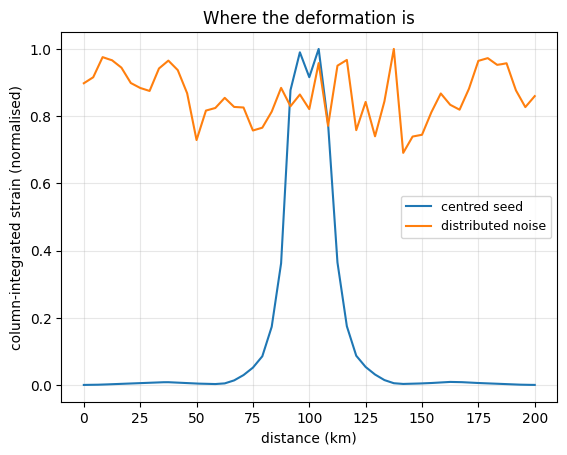

In [6]:
for tag, title in (("t12_centre", "centred seed"), ("t12_random", "distributed noise")):
    d = np.load(f"{tag}.npz")
    col = np.maximum(d["strain"], 0).sum(axis=0)
    plt.plot(d["x_km"], col / col.max(), label=title)
plt.xlabel("distance (km)")
plt.ylabel("column-integrated strain (normalised)")
plt.title("Where the deformation is")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

One curve has a single peak because we put one there. The other does not,
because we did not.

Extended to three crustal thicknesses over 60 steps, distributed seeding gives
(measured, prior runs):

| crust | $W_{50}$ | peak | relief | competing centres |
|---|---|---|---|---|
| 20 km | 0.425 | 1.26 | 1.92 km | **15** |
| 35 km | 0.347 | 1.74 | 4.23 km | **10** |
| 50 km | 0.409 | 1.79 | 1.63 km | **11** |

The last column is what settles it. Counting local maxima above half the peak,
every case has ten to fifteen competing centres and column-integrated strain at
both side walls within 20% of the maximum. **No axis has been selected in any
case.** The $W_{50}$ differences are variation within "diffuse", not a
narrow-versus-wide contrast — and $W_{50}$ alone would have supported the story.
Looking at where the strain actually sits killed it.

## 5. Attempt three: "just run it faster" — and why it cannot work

The obvious response is that 60 steps is not enough finite strain, and that
rifts run at 0.5–2 cm/yr rather than the 0.25 cm/yr used here. So raise the
extension rate.

**It does nothing, and the reason is instructive.** $U_0$ is the *velocity
scale*. Raising it rescales stress, strain rate, time, buoyancy and the Péclet
number together:

| group | effect of raising $U_0$ | consequence |
|---|---|---|
| $\sigma_y / (\mu_0 U_0 / H)$ | falls | yields more easily |
| $\dot\varepsilon = U_0/H$ | rises | creep viscosity falls ($n \approx 3$–4) |
| $\kappa/(U_0 H)$ | falls | Péclet rises, less conduction |
| $g H^2/(\mu_0 U_0)$ | falls | buoyancy matters less |

But the *time* scale is $H/U_0$, so one non-dimensional timestep is a shorter
real time in exactly the same proportion. **Total stretching is `steps × dt`,
and $U_0$ cancels out of it entirely.** Sixty steps at 1 cm/yr and sixty steps
at 0.25 cm/yr both give 12 km of extension.

Measured, at 60 steps and three crustal thicknesses:

| crust | $W_{50}$ at 0.25 cm/yr | at 1.0 cm/yr | peak at 0.25 | at 1.0 |
|---|---|---|---|---|
| 20 km | 0.425 | 0.440 | 1.26 | 0.99 |
| 35 km | **0.347** | 0.399 | 1.74 | 1.14 |
| 50 km | 0.409 | 0.415 | 1.79 | 1.30 |

Faster is *worse* in every column — more diffuse and less deformed. The lower
non-dimensional yield stress makes more of the domain yield at once, which
spreads deformation rather than concentrating it, and no extra finite strain
arrives to compensate.

**The knob that does buy finite strain is the timestep**, and the historical cap
of $2\times10^{-3}$ turned out to be about four times below what the CFL
condition permits.

## 6. Attempt four: more stretching, and the representational ceiling

So raise `--dt-max` from 2e-3 to 6e-3 and aim for 30% stretching instead of 12%.
Here is what happens.

In [7]:
big = run("t12_big", crust_km=35.0, steps=STEPS + 15, seed_mode="random",
          seed_amp=1.0, dt_max=6e-3)
stretch = 100 * big["steps_completed"] * big["dt_max"]
print(f"requested {big['steps_requested']} steps, completed {big['steps_completed']}")
print(f"stretching reached: {stretch:.1f}%")
print(f"failure: {big['failure']}")

requested 35 steps, completed 24
stretching reached: 14.4%
failure: AdvectionBroke: level set range [-0.0082, 1.0601] at step 23: the conservative level set must stay in [0, 1]. Everything downstream of the material field is now meaningless.


It aborts. The same happened at all three crustal thicknesses:

| crust | aborted at | stretching reached | surface displacement |
|---|---|---|---|
| 20 km | step 41 | 24.6% | −24 km |
| 35 km | step 24 | 14.4% | −17 km |
| 50 km | step 29 | 17.4% | −19 km |

The conservative level set leaves [0, 1] — the same representational limit T10
derived, reached here through large finite strain rather than through a thinning
neck. At 48×24 this model can carry roughly **15–25% stretching** before the
material description stops meaning anything.

That is the answer to the whole notebook. Mode selection in Buck's sense needs
tens of percent of stretching *and* enough resolution to keep the interfaces
representable while it happens. Those two requirements pull against each other,
and the budget for a teaching notebook does not span the gap.

## 7. What was actually learned

No narrow/wide diagram. Four things that are worth more:

**An initial condition can impose the answer.** The centred seed produces a
narrow rift at every crustal thickness from 20 to 50 km, including thicknesses
where the strength envelope predicts a wide one. If your model reproduces the
textbook figure, check whether you built the figure into the initial condition.

**Thresholds in a constitutive law are not decoration.** Seeding noise below the
weakening onset switched off the entire feedback loop, and the run looked
healthy while doing nothing.

**Know which of your knobs are real.** In this non-dimensionalisation the
extension rate cannot buy finite strain — it rescales the whole problem and
cancels from the total stretching. The timestep can. Working that out from the
scaling took ten minutes; discovering it by experiment took two sweeps.

**A distribution metric needs an amount beside it.** $W_{50}$ survived a
synthetic null test and still could not distinguish "spread out" from "hasn't
deformed" — that took peak strain, and in the end it took looking at the field.

## What it would take

Reaching the transition needs, in rough order of expense: enough resolution to
hold the interfaces to 30%+ stretching, which at the ~2 km cells used here means
128×64 or finer; enough steps to get there, several hundred; and probably a
domain wider than 200 km, since a wide rift is defined by spreading deformation
over a zone that a 200 km box may not contain. That is a research run, not a
notebook cell — and knowing the size of the gap is a more useful thing to hand a
student than a figure that came out right for the wrong reason.

## Extend this

* Re-run section 4 at 128×64 and see how much further the stretching gets before the invariant fires. Does the ceiling scale with cell size the way T10's necking limit did?
* Vary `--seed-amp` from 0.3 to 2.0 at fixed crustal thickness. Where does localisation switch on, and does it coincide with the weakening onset of 0.5?
* The 35 km case is consistently the most localised at every setting tried. Is that a real optimum, or the crustal thickness at which the brittle–ductile transitions happen to line up with the layer boundaries on this mesh?
* Count competing centres as a function of stretching for a single run. Do they merge over time, or does the model simply never select?
* Widen the domain to 400 km with the same cell size and repeat one case. Does the deformation still reach the walls?